# Krachtactuator Ontwerpopdracht

In de eerste 4 weken van het vak DEF-D hebben jullie simulaties gedaan van verschillende opstellingen in de electrostatica. Jullie zijn in week 3.6 bij het vak electromagnetisme doorgegaan met de magnetostatica. Deze opdracht gaat in op het simuleren van deze magnetostatica.

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

De opdracht bestaat uit de volgende sub-onderdelen:
1) Afleiden van een analytische vergelijking
2) Criteria opstellen
3) Simuleren om de grenzen van jullie ontwerpparameters te bepalen
4) Numeriek berekenen van het magneetveld
5) Numeriek berekenen van het magneetveld van een solenoide
6) Bereken krachtrespons van een kracht actuator
7) Beoordeling van de criteria

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.9 beoordeeld en herkansingen zijn in week 3.10, zie de studiehandleiding voor details.

Technische Instructies:
- Download de zip map die op brightspace staat en unzip deze.
- Creëer een nieuwe branch in je Github repo voor deze opdracht.
- Plaats de geunzipte map op de juiste plek in jouw branch, zoals in de handleiding op brightspace staat.
- Nodig je teamgenoot uit als collaborateur op jouw repo.

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Probeer de voorbeeld code te begrijpen.
- Op een aantal plekken zijn voorbeelden gegeven of bepaalde numerieke methodes sterk versimpeld. Deze code kunnen reprocuderen is niet een leerdoel van dit vak en zal later in de opleiding voorkomen. Denk hierbij aan het integreren en differentieeren, probeer deze dingen wel te begrijpen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# DEF-D opdracht 2: Ontwerp een solenoïdale krachtactuator


<img align="right" style="margin-left:15px" src="figures\solenoidactuator.png" width="600">


In deze ontwerpopdracht ga je een krachtactuator ontwerpen gebaseerd op een solenoïde en een permanente magneet. Deze lineaire krachtactuatoren worden gebruikt om bijvoorbeeld kleppen en afsluiters elektronisch te bedienen. Ook komen ze in vele huidshoudelijk apparaten voor. Hiernaast zie je een plaatje van een krachtactuator van de buitenkant en van de doorsnede. De krachtactuator bestaat uit een solenoïde (spoel), dat is een spiraalvormige stroomkring waar een stroom doorheen loopt. Zoals je weet kan je met een solenoide een redelijk homogeen veld maken als de solenoide lang en smal is. In de solenoïde  zit een cilinder,een zogeheten plunjer, die kan schuiven in de solenoïde. De plunjer is verbonden met het object dat je wilt bewegen. De plunjer kan gemaakt zijn van een magnetisch materiaal met een hoge magnetische permeabiliteit of van een permanente magneet. In dit voorbeeld kiezen we voor een plunjer van magnetiseerbaar materiaal.

Voor het ontwerpen van de actuator gaan we eerst de kracht van de actuator uitrekenen met behulp van analytische theorie. We nemen eerst aan dat de solenoïde ideaal is en leiden daarvoor een analytische vergelijking af. Nadat we een eerste ontwerp hebben gemaakt gebaseerd op de analytische oplossing gaan we simuleren hoe goed onze krachtactuator echt werkt en of we het ontwerp nog kunnen verbeteren. Daar gaan we!

## Deel 1: afleiden van een analytische vergelijking

Hier onder ze je een detaildoorsnede van de solenoïde. De solenoïde heeft een lengte $L_s$, $N$ wikkelingen, een straal $r_s$ en er loopt een constante stroom $I$ door de draad. De plunjer is een afstand $z_p$ in de solenoide geschoven en moet over een zo groot mogelijke afstand een kracht uitoefenen. Een ideale solenoïde heeft binnenin een constant veld dat overal langs de as is gericht, buiten de solenoïde is het veld nul. Daarnaast nemen we aan dat het magnetisch materiaal homogeen en lineair is en een relatieve permeabiliteit $\mu_r$ heeft.

<center>
<img src="figures\solenoidactuatorgraph.png" width="1000">
</center>

**Opdracht 1**

a. Pas de wet van Ampère toe voor het $\mathbf{H}$-veld met gebruik van contour $\cal C$.\
b. Leidt een vergelijking af voor het $\mathbf{B}$-veld als functie van $z_p$.\
c. Voldoet jouw afleiding aan de randvoorwaarden voor het H en B veld?

![image](figures/deel1_vraag1.png "H, B-veld afleiding")

Het randveld van de solenoïde zal de plunjer de solenoïde intrekken. Echter, het berekenen van de randvelden is een hele klus, we zullen dit later doen. We gebruiken hier een aanpak soortgelijk aan die voor een dielektricum in een condensator. Allereerst berekenen we de totale energie van het systeem met behulp van $W = \frac{1}{2} \int_{\cal V} \mathbf{H} \cdot \mathbf{B} \, d\tau $. Daarna bepalen we de kracht op de plunjer door de afgeleide van de energie naar de positie te nemen. We nemen aan dat de plunjer dezelfde straal heeft als de solenoide, $r_s$. 

**Opdracht 2**

Bereken de totale hoeveelheid energie in de solenoïde als functie van $z_d$ door de veldenergie over het volume van de solenoïde te integreren met behulp van bovenstaande vergelijking.

![image](figures/deel1_vraag2.png "energie van solenoïde")

Zoals je wellicht ziet uit je afleiding is de energie van de plunjer groter als de plunjer er geheel uit is en kleiner als de plunjer er geheel in is. De afgeleide van de energie naar de positie $z_p$ geeft dan ook een kracht die de plunjer naar buiten beweegt. Dit is fysisch niet wat er gebeurd. Wat we in de afleiding niet hebben meegenomen is de energie die het kost om de stroom te laten stromen. Het veranderende magneetveld veroorzaakt door het naar binnen bewegen van de magneet (wet van Faraday) geeft een stroom tegengesteld aan de aangelegde stroom, de stroombron moet dan dus meer vermogen gaan leveren om de stroom op gang te houden. Als we dit effect wel meenemen blijkt dat de grootte van de kracht gelijk is, maar dat deze dan de plunjer de solenoide intrekt. We gaan hier niet verder op in.


**Opdracht 3**

Bereken de kracht van de spoel op de plunjer.

![image](figures/Deel1_vraag3.png "kracht van spoel op plunjer")

## Deel 2: Criteria opstellen

Jullie gaan nu een magnetische kracht actuator ontwerpen hiervoor gaan jullie nu een ontwerpcyclus doorlopen.

**Opdracht 4**

a. Bedenk en schets vijf toepassingen van een kracht actuator.\
b. Kies uit deze toepassingen minimaal 2 toepassingen voor een kracht actuator om verder mee door te rekenen.

![image](figures/Deel2_vraag1.png "schetsen van toepassingen")

**Opdracht 5**

We gaan nu verder kijken naar de criteria van jullie kracht actuatoren. Wij hebben alvast twee essentiele criteria vastgesteld zodat we hier later in de opdracht mee verder kunnen rekenen. Hieronder zijn 4 veelgebruikte stroombronnen benoemd die jullie gaan gebruiken voor een van de criteria.

| Spanningsbron             | Stroomsterkte | Voltage | draad dikte van de spoel |
|:--------------------------|:--------------|:--------|:-------------------------|
| Arduino uno digital pin   | 40 mA         | 5 V     | 0.05 mm                  |
| 9 Volt batterij           | 500 mA        | 9 V     | 0.1  mm                  |
| 40 Watt telefoon oplader | 2 A           | 20 V    | 0.2 mm                   |
| Een auto batterij         | 180 A         | 12 V    | 1.5 mm                   |


a. Kies een van de hierboven benoemde stroombronnen om te gebruiken in jullie ontwerp. \
b. Gebruik de methode uit het college 'schattend rekenen' om voor elke toepassing de minimale kracht die de actuator moet kunnen leveren voor jullie toepassing te bepalen.\
c. Denk na over wat de straal van jullie actuator mag zijn. \
d. Bedenk nog 1 ander criterium per toepassing.

![image](figures/Deel2_vraag2.png "schattend rekenen")

c. 

Straal van potlood actuator: 1/3 cm = 0.0033 m\
Straal van deurslot actuator: 5 cm = 0.05 m

d. 

Potlood criterium: sterk genoeg voor de weerstand van het lood tegen de zijkant van de potlood en tegen het papier aan.\
Deurslot criterium: Kan snel open of dicht voor noodsituaties, moet ook uit een sterke metaal gemaakt woorden, zoals titaan. 

## Deel 3: Simuleren om de grenzen van jullie ontwerpparameters te bepalen

Jullie zullen nu simulaties gaan uitvoeren om de grenzen van jullie ontwerpparameters op te zoeken. Dit doen jullie voor jullie twee gekozen toepassingen en een deuractuator. Deze deuractuator moet een deur van het slot afhaalen door een kracht van 40 N uit te oefenen, gebruikt een 9 volt batterij als stroombron, de plunjer is gemaakt van ijzer en de straal van de actuator is 0.1 m.

**Opdracht 6**

Zet de relevante parameters in een Python script en maak een Python functie die met behulp van de wet van Ohm de maximale draadlengte uitrekent. Print de maximale draadlengte bij het uitvoeren van het script.

**Ohm's Wet:**

$V = I\cdot R$

**Draad weerstand:**

$R = \frac{L \cdot \rho}{A}$

**Lengte van draad:**

$L = \frac{V \cdot A}{I \cdot \rho}$

met $A = {\pi} \cdot r^2$

In [2]:
def lengte_draad(V, I, rho, r):
    A = np.pi * r**2
    L = (V * A) / (I * rho)
    return L

#straal en weerstand van het draad blijft constant
rho = 1.72e-8 #Ohm * meter, koper weerstand

#deurslot
V_deurslotopdracht = 9 #volt
I_deurslotopdracht = 0.5 #Amperes
r_deurslotopdracht = 1e-4 #meter

deurslotopdracht = np.round(lengte_draad(V_deurslotopdracht, I_deurslotopdracht, rho, r_deurslotopdracht))

print("De draad lengte voor de opdracht deurslot moet", deurslotopdracht, "meter zijn.")

#potlood
V_potlood = 5 #volt
I_potlood = 0.04 #Amperes
r_potlood = 5e-5 #meter

potlood = np.round(lengte_draad(V_potlood, I_potlood, rho, r_potlood))

print("De draad lengte voor de potlood moet", potlood, "meter zijn.")

V_deurslot = 20 #volt
I_deurslot = 2.0 #Amperes
r_deurslot = 2e-4 #meter

deurslot = np.round(lengte_draad(V_deurslot, I_deurslot, rho, r_deurslot))

print("De draad lengte voor de deurslot moet", deurslot, "meter zijn.")

De draad lengte voor de opdracht deurslot moet 33.0 meter zijn.
De draad lengte voor de potlood moet 57.0 meter zijn.
De draad lengte voor de deurslot moet 73.0 meter zijn.


**Opdracht 7**

Leidt een vergelijking af voor het minimale aantal wikkelingen $N$ die je nodig hebt om het gewicht op te kunnen tillen. Voeg je afleiding als png toe aan je notebook.

![Image](figures/Deel3_opdracht7.png "minimale aantal wikkelingen")

We gaan nu de ontwerpvrijheid verkennen. Gegeven de materiaalparameters en de eigenschappen van de stroombron kunnen we de verhouding tussen de lengte en de straal van de solenoide kiezen.

**Opdracht 8**

Schrijf een enkele Python functie die het minimum en maximum aantal wikkelingen uitrekent als functie van $L_s$, $r_s$, $r_d$ en $I$. De functie moet de volgende voorwaarden controleren
1) Het minimum aantal wikkelingen wordt gegeven door de hiervoor afgeleide relatie van het aantal wikkelingen om de benodigde kracht te genereren. 
2) Het maximum aantal wikkelingen wordt gegeven door de draaddikte $r_d$ en de lengte $L_s$
3) Het maximum aantal wikkelingen wordt gegeven door de draadlengte en de straal van de solenoide
4) Het maximum aantal wikkelingen moet groter zijn dan het minimum aantal wikkelingen

Het maximum aantal wikkelingen is de kleinste van voorwaarde 2) en 3). Geef een foutmelding als het minimum aantal windingen groter is dan het maximum aantal windingen.

![Image](figures/Deel3_opdracht8.png "aantal wikkelingen afleiding")

In [3]:
### BEGIN SOLUTION
mu_0 = 4 * np.pi * 1e-7 #magnetische permeabilteit in vacuum
mu_r = 5 * 1e3 # permeabiliteit voor ijzer

def aantal_wikkelingen(L_s, r_s, r_d, I, L_draad, F):
    # Voeg hieronder de formules voor het maximum en minimum aantal wikkelingen.
    N_min = np.sqrt((2 * L_s**2 * F) / (mu_0 * np.pi * r_s**2 * I**2 * (mu_r -1)))
    N_max_1 = L_s / (2 * r_d)
    N_max_2 = L_draad / (2 * np.pi * r_s)

    N_max = np.minimum(N_max_1, N_max_2)

    for i in range(len(L_s)):
        if N_min[i] > N_max[i]: ## Als het ontwerp niet mogelijk is.
            print('The design with %.2f unit has no workable solution'%L_s)

        mask = N_min > N_max

        N_min[mask] = 'NaN'
        N_max[mask] = 'NaN'
            
    return N_min, N_max

Een parameter plot geeft ons inzicht in de haalbaarheid van het idee. In dit geval willen we kijken naar het mogelijke aantal wikkelingen en de lengte van onze solenoide. Hieronder staat een voorbeeld van code die een voorbeeld plot creëert met minimale eis $y=x$ en de maximale eis $y=2x$.

Text(0, 0.5, 'y')

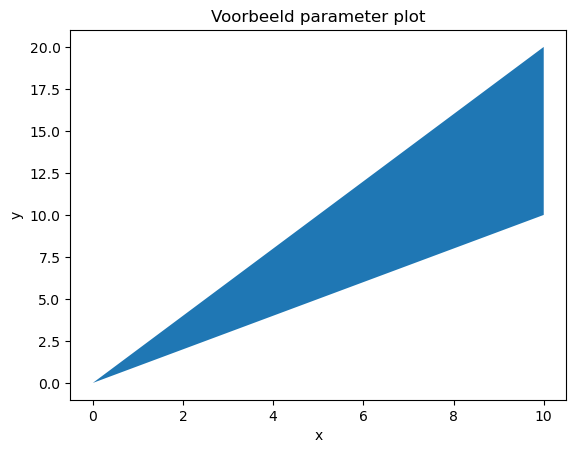

In [4]:
x = np.linspace(0,10,100)
y_min = x # Minimale eis
y_max = 2*x # Maximale eis

plt.fill_between(x,y_min,y_max) # De ruimte tussen de eisen vullen
plt.title("Voorbeeld parameter plot")
plt.xlabel("x")
plt.ylabel("y")


**Opdracht 9**

Maak een parameterplot met behulp van bovenstaand gedefinieerde functie voor de drie solenoideactuatoren voor $L_s$ tussen 0 en 1 m in 50 stappen. Een parameter plot ziet er hier uit als een plot tussen het minimale aantal wikkelingen en het maximaal aantal wikkelingen.



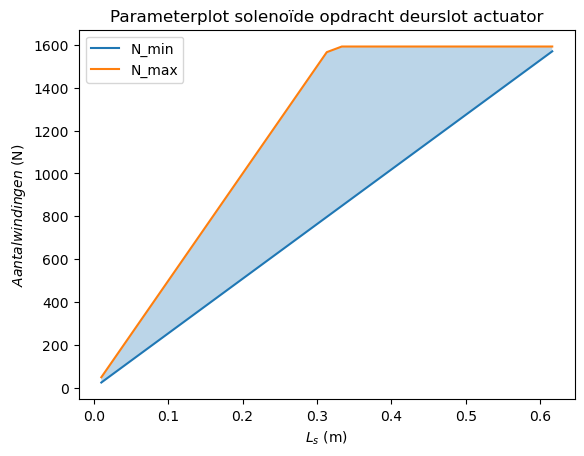

In [5]:
L_s = np.linspace(0.01, 1, 50)

#deurslot opdracht

r_sdeurslotopdracht = 0.05 #meter, dit is niet de gegeven waarden van 0.01 meter, maar die werkte niet
I_deurslotopdracht = 0.5 #Amperes
r_ddeurslotopdracht = 1e-4 #meter
F_deurslotopdracht = 40 #newton

N_mindeurslotopdracht, N_maxdeurslotopdracht = aantal_wikkelingen(L_s, r_sdeurslotopdracht, r_ddeurslotopdracht, I_deurslotopdracht, 500, F_deurslotopdracht)

plt.figure()

plt.plot(L_s, N_mindeurslotopdracht, label="N_min")
plt.plot(L_s, N_maxdeurslotopdracht, label="N_max")

plt.fill_between(L_s, N_mindeurslotopdracht, N_maxdeurslotopdracht, alpha=0.3)

plt.xlabel("$L_s$ (m)")
plt.ylabel("$Aantal windingen$ (N)")
plt.title("Parameterplot solenoïde opdracht deurslot actuator")
plt.legend()

plt.show()

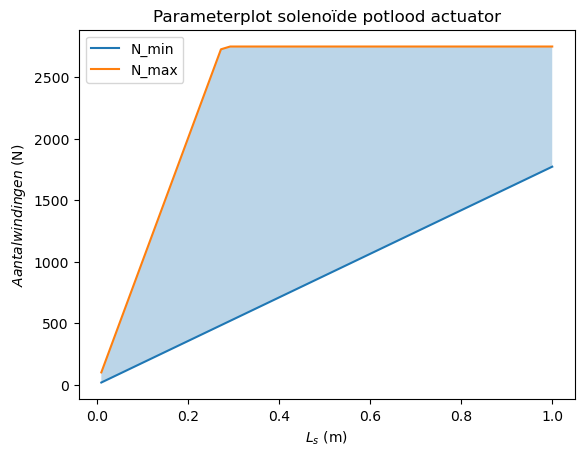

In [6]:
#potlood

r_spotlood = 0.0033 #meter
I_potlood = 0.04 #Amperes
r_potlood = 5e-5 #meter
F_potlood = 5.4e-4 #newton

N_minpotlood, N_maxpotlood = aantal_wikkelingen(L_s, r_spotlood, r_potlood, I_potlood, potlood, F_potlood)

plt.figure()

plt.plot(L_s, N_minpotlood, label="N_min")
plt.plot(L_s, N_maxpotlood, label="N_max")

plt.fill_between(L_s, N_minpotlood, N_maxpotlood, alpha=0.3)

plt.xlabel("$L_s$ (m)")
plt.ylabel("$Aantal windingen$ (N)")
plt.title("Parameterplot solenoïde potlood actuator")
plt.legend()

plt.show()

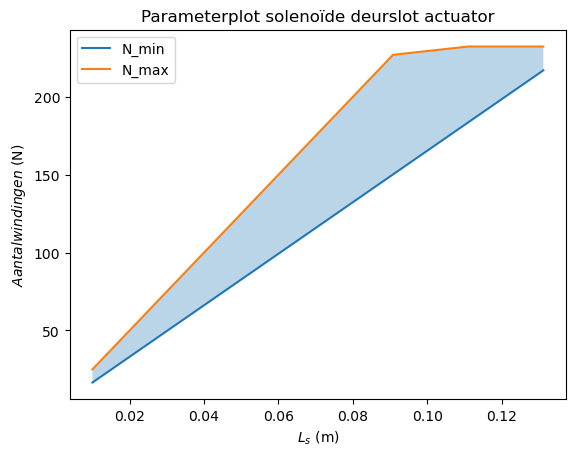

In [7]:
#deurslot, grotere spanningsbron gekozen, (40 Watt telefoon oplader)

r_sdeurslot = 0.05 #meter
I_deurslot = 2.0 #Amperes
r_ddeurslot = 2e-4 #meter
F_deurslot = 270 #newton

N_mindeurslot, N_maxdeurslot = aantal_wikkelingen(L_s, r_sdeurslot, r_ddeurslot, I_deurslot, deurslot, F_deurslot)

plt.figure()

plt.plot(L_s, N_mindeurslot, label="N_min")
plt.plot(L_s, N_maxdeurslot, label="N_max")

plt.fill_between(L_s, N_mindeurslot, N_maxdeurslot, alpha=0.3)

plt.xlabel("$L_s$ (m)")
plt.ylabel("$Aantal windingen$ (N)")
plt.title("Parameterplot solenoïde deurslot actuator")
plt.legend()

plt.show()

**Opdracht 10**

Maak voor elke actuator een keuze voor de lengte van de spoel, de straal van de spoel en de lengte van de draad.

a. opdracht deurslot:

 -L_s: 0.3 meter\
 -r_s: 0.05 meter\
 -L_draad: 500.0 meter

b. potlood: 

 -L_s: 0.25 meter\
 -r_s: 0.0033 meter\
 -L_draad: 57.0 meter

c. deurslot: 

 -L_s: 0.1 meter\
 -r_s: 0.05 Amperes\
 -L_draad: 33.0 meter

Bovenstaande analytische berekening is een goede start voor het ontwerp en geeft aan welke parameters je kan optimaliseren. Echter in een echte solenoide zullen er allerlei niet ideale effecten een rol spelen. Zo zal het veld in de solenoide niet constant zijn (het is geen oneindig lange solenoide) en zijn er randvelden aan de uiteinden van de solenoide. We zullen nu de kracht-afstand relatie van de solenoide krachtactuator uitrekenen. Deze kan dan verder geoptimaliseerd worden om de kracht-uitwijking relatie zo lineair mogelijk te maken.

## Deel 4: Numeriek berekenen van het magneetveld van een rechte stroomdraad

<img align="right" style="margin-left:15px" src="figures/wiregeometry.png" width="300">

Omdat we in ons ontwerp een stroombron gebruiken met een aangelegde stroom voeren we de berekeningen uit met het $\mathbf{H}$-veld. De analytische oplossing voor het $\mathbf{H}$-veld om een oneindig lange stroomdraad is het met meest eenvoudige voorbeeld voor het berekenen van het magnetisch veld en het toepassen van de wet van Ampere. In cilindrische coordinaten wordt het magneetveld op afstand $s$ veroorzaakt door stroom $I$ gegeven door (zie Griffiths blz. 282, voorbeeld 6.2)
$$
    \mathbf{B} =\frac{I}{2 \pi s} \hat{\boldsymbol{\phi}} \, .
$$


Alleen in de meest eenvoudige stroomgeometrieën kunnen we het magneetveld analytisch berekenen. In meer complexe stroomgeometrieën moeten we numerieke methoden gebruiken om het magneetveld te berekenen. In deze opdracht willen we een numerieke methode ontwikkelen voor een complexe stroomgeometrie, maar gebruiken we het voorbeeld van de oneindig lange stroomdraad om onze numerieke methode te testen. We gaan het magneetveld berekenen met de wet van Biot-Savart (zie Griffiths blz. 222, Vgl. 5.34) maar dan voor het $\mathbf{H}$-veld

$$
    \mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I \int \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

De wet van Biot-Savart laat zien dat het magneetveld wordt gegeven door een som over lijnelementen $d\mathbf{l}$ met bijdrage

$$
    d\mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I  \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

**Opdracht 11**

Schrijf een Python functie met als invoer de variabelen:
* een array die de veldpositie $\mathbf{r}$ aangeeft
* een array die de de bronpositie $\mathbf{r}'$ aangeeft
* een array die de lengte $d\mathbf{l}$ aangeeft

De functie moet het magneetveld van een lijnelement $d\mathbf{l}$ berekenen. Gebruik voor het uitrekenen van het uitproduct de numpy $\verb|cross|$ functie en de hierboven gegeven formule voor $d\mathbf{H}$.

Bereken met deze functie alle componenten van het magneetveld voor een veldpositie op $x=0.1$ m voor een stroombronelement in de oorsprong met een stroom van 6 A een lengte van $d\mathbf{l}$ gelijk aan $L/64$. Print het analytische en numerieke antwoord naar de command line en controleer dat het magneetveld gelijk is aan $\mathbf{H} =  0.00746 \hat{\mathbf{y}}$ A/m is.

In [8]:
r_field=np.array([0.1, 0, 0])
r_source=np.array([0, 0, 0])
I = 6
L_draad = 0.1
dl=np.array([0, 0, L_draad/64])

def field_current_element(r_field, r_source, dl):
    # r_field are coordinates at which we want to calculate the field
    # r_source are coordinates of the current source
    # dl is the vector of the length of the current element
    # Gebruik np.cross om het uitproduct te berekenen
    r_diff = r_field - r_source
    r_hat = r_diff / np.linalg.norm(r_diff) #Eenheidsvector van r_diff maken
    dH = (I/(4*np.pi)) * np.cross(dl, r_hat) / np.linalg.norm(r_diff)**2
    return dH
analytical_answer=(I/4/np.pi)*(L_draad/64)/np.sum((r_field-r_source)**2) # een veld elementje.
print('The analytical answer is ' + str(analytical_answer) + ' A/m in the y-direction')

print('The numerical answer is ' + str(field_current_element(r_field, r_source, dl)) + ' A/m')

The analytical answer is 0.07460387957432593 A/m in the y-direction
The numerical answer is [0.         0.07460388 0.        ] A/m


De H is precies een factor 10 te groot (het antwoord dat in de vraag wordt gegeven volgt uit L_draad = 0.01).

Nu gaan we met behulp van de numerieke implementatie van de wet van Biot-Savart het magneetveld uitrekenen in het vlak loodrecht op de draad. We nemen daarom een eindige lengte van de draad en verdelen dit in kleine stukken met lengte $d\mathbf{l}$. Daarna integreren we over de gehele lengte door de bijdrage van al deze stukken op te tellen en zo het magneetveld te bepalen. Voor het correct uitvoeren van deze numerieke integratie is het van belang dat we en een lang genoeg stuk draad nemen en dat we dit in genoeg kleine delen ophakken.

**Opdracht 12**
* Creëer een array met de veldcoordinaat $\mathbf{r}$.
* Bereken een array met alle contributies $dH$ op $r=(x,y,z)=(0.1, 0, 0)$ m.
* Plot de contributies tegen de locatie van de bijbehorende bron.
* Bereken het $H$ veld door over alle contributies te someren.
* Print een regel met het numerieke antwoord en vergelijk dit met het analytische antwoord.
* Bestudeer hoe de bijdragen varieren voor de verschillende locaties en hoe groot L en het aantal stappen moet zijn om een numeriek correct resultaat te krijgen.

Deze opdracht kan ook gemaakt worden met het gebruik van for loops, De keuze voor methode is aan jullie.

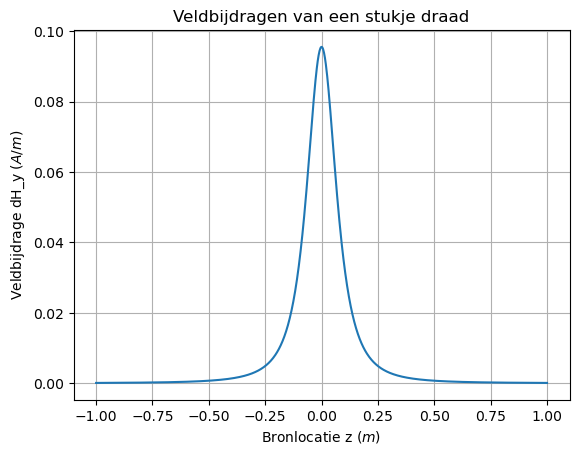

Numerieke antwoord: 9.501999322040119 A/m in de y-richting
Analytische antwoord: 9.549296585513721 A/m


In [9]:
#Waardes die ik heb gebruikt voor de veldberekening:
I = 6 #stroom in Ampere
r_field=np.array([0.1, 0, 0]) #veldpunt
L = 2 #totale draadlengte in meter, hoe groter hoe beter de benadering van een oneindige draad
N = 1000 #aantal stukjes waar we de draad in verdelen

#we gebruiken de veldberekining van een klein stukje draad, zoals in de vorige opdracht
def field_current_element(r_field, r_source, dl):
    r_diff = r_field - r_source
    r_hat = r_diff / np.linalg.norm(r_diff) #Eenheidsvector van r_diff maken
    dH = (I/(4*np.pi)) * np.cross(dl, r_hat) / np.linalg.norm(r_diff)**2
    return dH

#Draad verdelen langs de z-as van -L/2 tot L/2 met N stukjes
z_source = np.linspace(-L/2, L/2, N) #coordinaten van de bronpunten van elk stukje draad
dz = z_source[1] - z_source[0] #lengte van elk stukje draad
dl = np.array([0, 0, dz]) #dl vector in de z-richting

#Lijsten om alle bijdragen van elk stukje draad op te slaan
dH_all = []

#bereken de bijdrage van elk stukje draad en sla deze op in dH_all
for z in z_source:
    r_source = np.array([0, 0, z]) #coordinaten van het bronpunt van het huidige stukje draad
    dH = field_current_element(r_field, r_source, dl) #bereken de veldbijdrage van dit stukje draad
    dH_all.append(dH) #sla de bijdrage op

#Zet dH_all om in een numpy array voor makkelijke bewerkingen
dH_all = np.array(dH_all)
#Tel alle bijdragen bij elkaar op om het totale veld te krijgen
H_total = np.sum(dH_all, axis=0)

#Het analytische antwoord voor een oneindig lange draad
H_analytical = (I/(2*np.pi*0.1))

#plotten van de y-component van elke bijdragen tegen de bronlocatie z
plt.plot(z_source, dH_all[:,1]) #y-component van de veldbijdrage
plt.xlabel('Bronlocatie z ($m$)')
plt.ylabel('Veldbijdrage dH_y ($A/m$)')
plt.title('Veldbijdragen van een stukje draad')
plt.grid(True)
plt.show()

#Print de vergelijking van het numerieke en analytische antwoord
print('Numerieke antwoord:', H_total[1], 'A/m in de y-richting')
print('Analytische antwoord:', H_analytical, 'A/m')

### Deel 5: Numeriek berekenen van het magneetveld van een solenoide

We gaan nu het magneetveld van onze solenoide uitrekenen. Deze solenoide is een draad die om een cylinder gewikkeld is. Hieronder is een functie gegeven die de draad van een solenoide parametriseert. Deze parametrisatie gaan jullie gebruiken in combinatie met Biot-Savart om het H veld rond de solenoide te berekenen.

In [10]:
def parametrisatie(N,r_sol,aantal_omwentelingen,L_sol):
    t=np.linspace(0, 1, N)
    x = r_sol * np.cos(2 * np.pi * aantal_omwentelingen*t) # x coordinaten
    y = r_sol * np.sin(2 * np.pi * aantal_omwentelingen*t) # y coordinaten
    z = L_sol* t - L_sol/2  # z componenten
    return x,y,z

**Opdracht 13**

Bereken het traject van een stroomdraad met een straal van $r_{sol}$. De solenoide met lengte $L_{sol}$ is gecentreerd op de oorsprong met de cilinderas langs de $z$-as. Doe dit door de hierboven gegeven functie te gebruiken.

a. Bereken het aantal omwentelingen van je draad, hierbij mag je aannemen dat de omtrek een cirkel is (in feite is het een ellips, maar omdat de windingen zo dicht op elkaar zitten is het vrijwel een cirkel).\
b. Bereken de $x$, $y$ en $z$ coordinaten.\
c. Bereken de spoed, in eenheden van aantal omwentelingen per meter, en print dit.

De spoed van de draad is 795.7747154594765 omwentelingen per meter


(Text(0.5, 0, 'x (m)'), Text(0.5, 0.5, 'y (m)'), Text(0.5, 0, 'z (m)'))

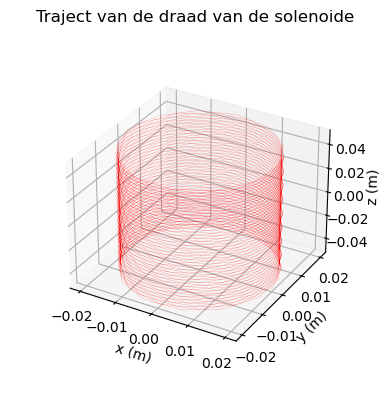

In [11]:
l_draad = 10 # Lengte draad
r_sol = 0.02 # Straal solenoide
L_sol = 0.1 # Lengte solenoide
N = 1000 # Aantal wikkeling

#aantal omwentelingen berekenen met aanname dat de omtrek een cirkel is
aantal_omwentelingen = l_draad / (2 * np.pi * r_sol)

# Parametrisatie van de draad van de solenoide
x,y,z = parametrisatie(N,r_sol,aantal_omwentelingen,L_sol)

#berekenen van spoed van de draad met eenheid aantal omwentelingen per meter
spoed = aantal_omwentelingen / L_sol #omwentelingen per meter
print('De spoed van de draad is', spoed, 'omwentelingen per meter')

# Enkele plots
ax=plt.figure().add_subplot(projection='3d')
plt.title('Traject van de draad van de solenoide')
plt.plot(x, y, z, '-r', linewidth=0.1)
ax.set_box_aspect(aspect=None, zoom=0.8)
ax.set_xlabel('x (m)'), ax.set_ylabel('y (m)'), ax.set_zlabel('z (m)')

Het veld in een oneindig lange solenoide wordt gegeven door $\mathbf{H} = n I \hat{\mathbf{z}}$, met $n$ de spoed van de draad, en $I$ de stroom.

**Opdracht 14**

Bereken het veld in het midden van de solenoide en vergelijk het met het analytische antwoord voor een oneindig lange solenoide. Verhoog $N$ net zo lang tot jullie antwoord convergeert naar het analytisch antwoord.
* Denk na over wat dl betekent en hoe jullie deze zou berekenen.
* Bereken met de functie die jullie eerder geschreven hebben de contributies aan het $H$-veld en sommeer deze.

In [12]:
#een deel van de vorige vragen is herhaald, want om de analytische waarde te naderen moet solenoide langer worden
l_draad = 10 # Lengte draad
r_sol = 0.02 # Straal solenoide
L_sol = 1 # Lengte solenoide
N = 10000 # Aantal wikkeling

#aantal omwentelingen berekenen met aanname dat de omtrek een cirkel is
aantal_omwentelingen = l_draad / (2 * np.pi * r_sol)

# Parametrisatie van de draad met N punten
x,y,z = parametrisatie(N,r_sol,aantal_omwentelingen,L_sol)

#berekenen van spoed van de draad met eenheid aantal omwentelingen per meter
spoed = aantal_omwentelingen / L_sol #omwentelingen per meter

#midden van de solenoide
r_miden = np.array([0, 0, 0])

#bereken de bijdragen van alle segmenten van de draad
dH_all = []
for i in range(N-1):
    r_source = np.array([x[i], y[i], z[i]]) #coordinaten van het bronpunt van het huidige stukje draad
    dl = np.array([x[i+1] - x[i], y[i+1] - y[i], z[i+1] - z[i]]) #dl vector van dit stukje draad
    dH = field_current_element(r_miden, r_source, dl) #bereken de veldbijdrage van dit stukje draad
    dH_all.append(dH) #sla de bijdrage op

#sommeer alle bijdragen
dH_all = np.array(dH_all)
H_total = np.sum(dH_all, axis=0)

#analytisch antwoord voor oneindig lange solenoide
H_analytical = spoed * I
print('Numerieke antwoord:', H_total[2], 'A/m in de z-richting.')
print('Analytische antwoord:', H_analytical, 'A/m in de z-richting.')

Numerieke antwoord: 476.8845155395842 A/m in de z-richting.
Analytische antwoord: 477.46482927568593 A/m in de z-richting.


### Deel 6: Bereken krachtrespons van een kracht actuator
Omdat onze solenoide niet oneindig lang is zal het veld in de solenoide niet uniform zijn en ook niet op alle plaatsen exact langs de as gericht zijn.

**Opdracht 15**

Bereken de $z$-component van het $\mathbf{H}$-veld op de as van de solenoide over het interval $z \in [0, 1.5L_s]$ in 25 stappen. Je moet nu dus op elk veld-punt met behulp Biot-Savart de bijdragen van alle stroomelementen integreren. Maak een grafiek van de $z$-component van het $\mathbf{H}$-veld tegen $z$.

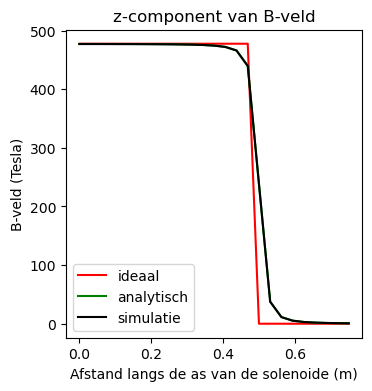

In [13]:
n_ax=25
z_ax=np.linspace(0, 1.5*L_sol/2, n_ax)
H_ax=np.zeros((n_ax,1))

for i_field in range(n_ax):
    #print(f"\rIfield =  {i_field}", end="") ik heb print statements uitgezet, zodat de code sneller draait
    # Bepaal de field coordinate
    r_field=np.array([0, 0, z_ax[i_field]])

    Hsimulated=np.array([0,0,0], dtype='float64')
    for i_source in np.arange(1, N):
        # Bepaal dl en r_source en gebruik
        r_source = np.array([x[i_source-1], y[i_source-1], z[i_source-1]]) #coordinaten van het bronpunt van het huidige stukje draad
        dl = np.array([x[i_source] - x[i_source-1], y[i_source] - y[i_source-1], z[i_source] - z[i_source-1]]) #dl vector van dit stukje draad

        Hsimulated += field_current_element(r_field, r_source, dl)
        #print(f"Ifield =  {i_field}", end="") ik heb print statements uitgezet, zodat de code sneller draait

    # selecting the z-component
    H_ax[i_field,0]=Hsimulated[2]

H_veld_ideaal=spoed*I*np.ones(n_ax)*(1.0*(z_ax < L_sol/2))

# dit is nog een aardige analytische uitdrukking die je kan uitrekenen voor de z-component op de as van een solenoide met eindige lengte
H_veld_analytisch=(aantal_omwentelingen*I/L_sol/2)*((L_sol/2-z_ax)/np.sqrt((z_ax- L_sol/2)**2 + r_sol**2)+(L_sol/2+z_ax)/np.sqrt((z_ax+ L_sol/2)**2 + r_sol**2))

plt.figure(figsize=[13,4])
plt.subplot(131)
plt.title('z-component van B-veld')
plt.plot(z_ax, H_veld_ideaal, '-r', label='ideaal')
plt.plot(z_ax, H_veld_analytisch, '-g', label='analytisch')
plt.plot(z_ax, H_ax, '-k', label='simulatie')
plt.xlabel('Afstand langs de as van de solenoide (m)')
plt.ylabel('B-veld (Tesla)')
plt.legend()
plt.show()

We gaan de solenoide nu gebruiken voor onze krachtactuator. Daarvoor gaan we opnieuw de energie in het magnetisch veld berekenen, maar nu met het numerieke resultaat voor een eindige lengte solenoide. We gaan hier nu een aantal aannames maken:
* We nemen aan het veld alleen een $z$-component heeft en niet afhangt van de afstand tot de solenoide as
* We verwaarlozen de bijdrage aan de energie van het deel van de solenoide gevuld in lucht en integreren alleen het deel van ijzer in het $\mathbf{H}$ veld (dat mag omdat $\mu_r \gg 1$)
* De plunjer is oneindig lang

Zoals je uit je berekening voor het $\mathbf{H}$ kan zien is de energie van de plunjer in de solenoide groter dan voor de plunjer uit de solenoide. Dit komt doordat we de berekening doen met constante stroom. De verplaatsing van de plunjer geeft echter ook een veranderende flux ($d \Phi/dt$) die een tegen EMF geeft. Deze moet overwonnen worden door de stroombron die de arbeid levert. Het magneetveld verricht dus geen arbeid, dat doet de stroombron! We berekenen dit effect hier niet expliciet, maar nemen $-W$ als energie zodat de kracht de juiste kant op wijst (de solenoide in, dus een kracht in de $-z$ richting).


**Opdracht 16**

* Bereken de energie als functie van de afstand van de plunjer in de solenoide met behulp van onderstaand script

(Text(0.5, 0, 'Afstand van plunjer in solenoide (m)'),
 Text(0, 0.5, 'Energie (J)'),
 None)

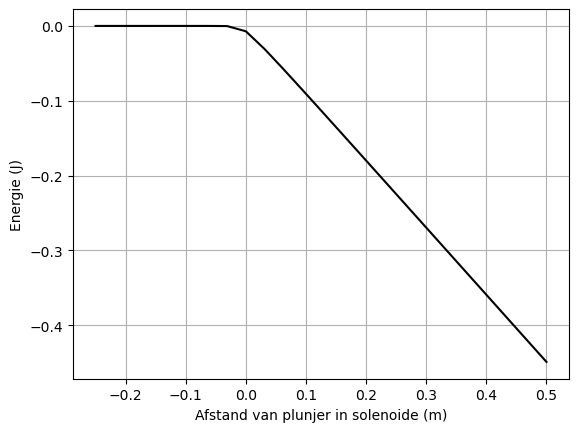

In [14]:
# integrate the field up to point z_p
Wz=-0.5*np.pi*r_sol**2*np.cumsum(np.flipud(H_ax)*mu_r*mu_0*np.flipud(H_ax))*(z_ax[1] - z_ax[0])

plt.plot(L_sol/2 - z_ax, np.flipud(Wz), '-k')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Energie (J)'), plt.grid()

(-200.0, 0.0)

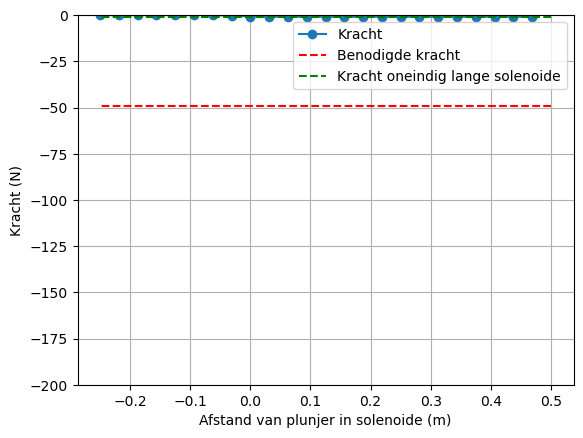

In [15]:
force_analytical = -mu_0*mu_r*np.pi*r_sol**2*aantal_omwentelingen**2*I**2/2/L_sol**2 # Kracht uitrekenen numeriek
force_numerical=np.diff(Wz, n=1, append=[0])/(z_ax[1] - z_ax[0]) # Kracht uitrekenen

# Plotting the results
plt.plot(L_sol/2 - z_ax, np.flipud(force_numerical), '-o', label='Kracht')
plt.plot(L_sol/2 - z_ax, (-5*9.8)*np.ones(n_ax), '--r', label='Benodigde kracht')
plt.plot(L_sol/2 - z_ax, force_analytical*np.ones(n_ax), '--g', label='Kracht oneindig lange solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Kracht (N)'), plt.grid(), plt.legend()
plt.ylim([-200, 0])


### Deel 7: Beoordeling van de criteria
**Opdracht 17**

Kijk in deze vraag terug naar de criteria die jullie voor de deuractuator hebben opgesteld. Voldoet jullie ontwerp aan alle gestelde criteria?


Uit alle simulaties blijkt dat de kracht van de solenoïde slechts een paar Newton is. Volgens de ontwerpeisen in deel 3 moest de deuractuator 40N leveren, dit haalt hij dus niet. Ook de benodigde kracht uit de berekening in opdracht 16 van 49N haalt de solenoïde niet. Dit komt doordat het magnetische veld in de relatief lange solenoïde vrijwel uniform is, hierdoor is er een erg kleine veldgradiënt, en dus een kleine kracht op de plunjer.

**Opdracht 18**

Voer opdrachten 15 en 16 uit voor jouw eigen gekozen toepassingen.

In [16]:
mu_0 = 4*np.pi*1e-7 #magnetische permeabiliteit in vacuum (opgezocht)
mu_r = 5e3   #ijzer

#Alle functies die we nodig hebben voor de simulatie van onze gekozen toepassingen heb ik gehaald uit de vorige opdrachten, maar ik heb ze een andere naam gegeven, zodat ze makkelijker te gebruiken zijn in de volgende opdrachten.
def field_current_element(r_field, r_source, dl, I):
    r_diff = r_field - r_source
    r_norm = np.linalg.norm(r_diff)

    if r_norm == 0:
        return np.array([0.0, 0.0, 0.0])

    r_hat = r_diff / r_norm
    dH = (I/(4*np.pi)) * np.cross(dl, r_hat) / (r_norm**2)
    return dH


def parametrisatie_draad(N_punten, r_sol, L_sol, N_windingen):
    t = np.linspace(0, 1, N_punten)
    x = r_sol * np.cos(2*np.pi*N_windingen*t)
    y = r_sol * np.sin(2*np.pi*N_windingen*t)
    z = L_sol * t - L_sol/2
    return x, y, z



#Deze functie combineert alle stappen die we hebben gedaan in de vorige opdrachten om de veld, energie en kracht te berekenen voor een gegeven set parameters van de solenoide en de benodigde kracht. Deze functie kunnen we straks gebruiken voor onze toepassingen.
#Dit is dus 1 functie die alle stapppen doorloopt van de vorige opdrachten.
def simuleer_actuator(L_sol, r_sol, I, N_windingen, benodigde_kracht, mu_r=5e3,
                      n_draadpunten=3000, n_ax=25):

    #draad parametriseren
    x, y, z = parametrisatie_draad(n_draadpunten, r_sol, L_sol, N_windingen)

    #veldpunten op de as
    z_ax = np.linspace(0, 1.5*L_sol, n_ax)
    H_ax = np.zeros(n_ax)

    #H_z op de as berekenen
    for i_field in range(n_ax):
        r_field = np.array([0.0, 0.0, z_ax[i_field]])

        H_total = np.array([0.0, 0.0, 0.0])

        for i_source in range(1, n_draadpunten):
            r_source = np.array([x[i_source-1], y[i_source-1], z[i_source-1]])
            dl = np.array([
                x[i_source] - x[i_source-1],
                y[i_source] - y[i_source-1],
                z[i_source] - z[i_source-1]
            ])

            H_total += field_current_element(r_field, r_source, dl, I)

        H_ax[i_field] = H_total[2]

    #alleen ijzerdeel integreren zoals in de opdracht
    dz = z_ax[1] - z_ax[0]
    Wz = -0.5 * np.pi * r_sol**2 * np.cumsum(np.flipud(H_ax) * mu_r * mu_0 * np.flipud(H_ax)) * dz

    #kracht numeriek
    F_num = np.diff(Wz, append=Wz[-1]) / dz

    #analytische benadering oneindig lange solenoïde
    F_anal = -mu_0 * mu_r * np.pi * r_sol**2 * N_windingen**2 * I**2 / (2 * L_sol**2)

    #grafiek H_z
    plt.figure()
    plt.plot(z_ax, H_ax, '-o')
    plt.xlabel('z (m)')
    plt.ylabel('$H_z$ (A/m)')
    plt.title(f'H-veld op as')
    plt.grid()

    #grafiek energie
    plt.figure()
    plt.plot(L_sol/2 - z_ax, np.flipud(Wz), '-k')
    plt.xlabel('Afstand van plunjer in solenoide (m)')
    plt.ylabel('Energie (J)')
    plt.title(f'Energie')
    plt.grid()

    #grafiek kracht
    plt.figure()
    plt.plot(L_sol/2 - z_ax, np.flipud(F_num), '-o', label='Kracht numeriek')
    plt.plot(L_sol/2 - z_ax, benodigde_kracht*np.ones_like(z_ax), '--r', label='Benodigde kracht')
    plt.plot(L_sol/2 - z_ax, F_anal*np.ones_like(z_ax), '--g', label='Oneindig lange solenoide')
    plt.xlabel('Afstand van plunjer in solenoide (m)')
    plt.ylabel('Kracht (N)')
    plt.title(f'Krachtrespons')
    plt.grid()
    plt.legend()

    plt.show()

    print('maximale numerieke kracht =', np.max(np.abs(F_num)), 'N')
    print('benodigde kracht =', benodigde_kracht, 'N')
    print('analytische kracht =', abs(F_anal), 'N')

    if np.max(np.abs(F_num)) >= benodigde_kracht:
        print('Conclusie: voldoet aan het krachtcriterium.')
    else:
        print('Conclusie: voldoet NIET aan het krachtcriterium.')

    return z_ax, H_ax, Wz, F_num

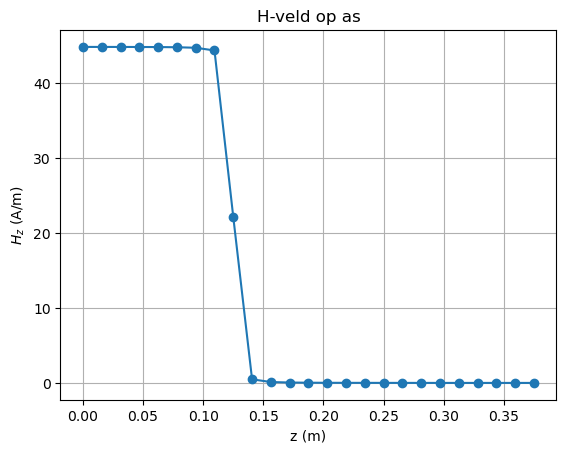

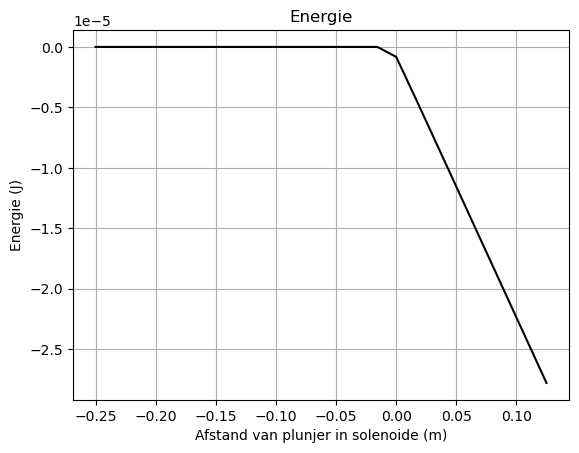

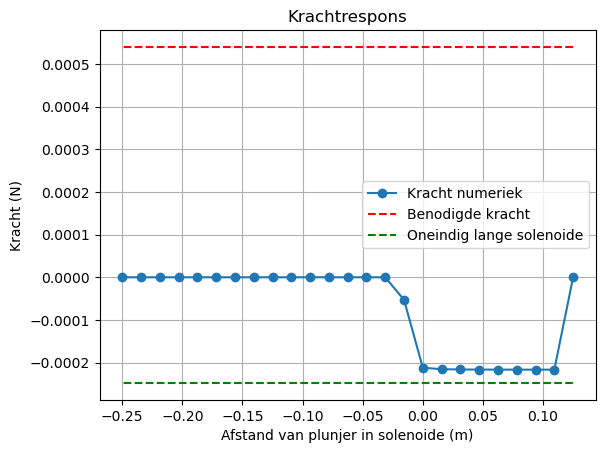

maximale numerieke kracht = 0.00021654391818338894 N
benodigde kracht = 0.00054 N
analytische kracht = 0.0002476339014017966 N
Conclusie: voldoet NIET aan het krachtcriterium.


In [17]:
#Potlood simulatie, ik heb de straal van de solenoide iets groter gemaakt dan de gegeven 0.01 meter, omdat dat anders geen oplossing gaf. De benodigde kracht is berekend op basis van het gewicht van een potlood van 5 gram.
L_sol_potlood = 0.25
r_sol_potlood = 0.0033
I_potlood = 0.04
N_potlood = 300
F_potlood = 5.4e-4

z_ax_potlood, H_ax_potlood, Wz_potlood, F_num_potlood = simuleer_actuator(
    L_sol=L_sol_potlood,
    r_sol=r_sol_potlood,
    I=I_potlood,
    N_windingen=N_potlood,
    benodigde_kracht=F_potlood
)

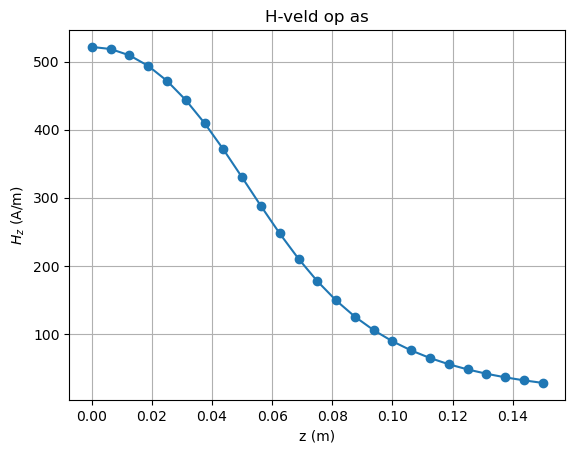

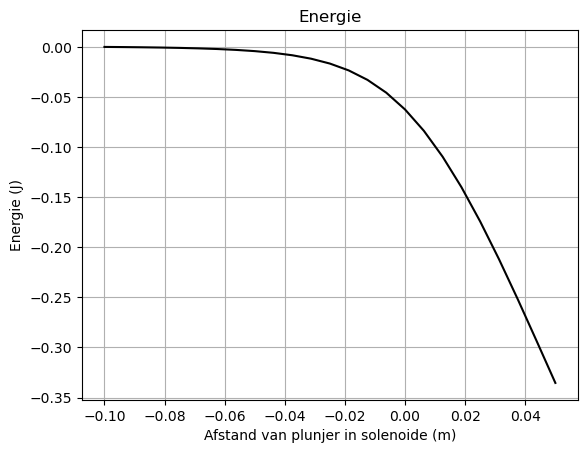

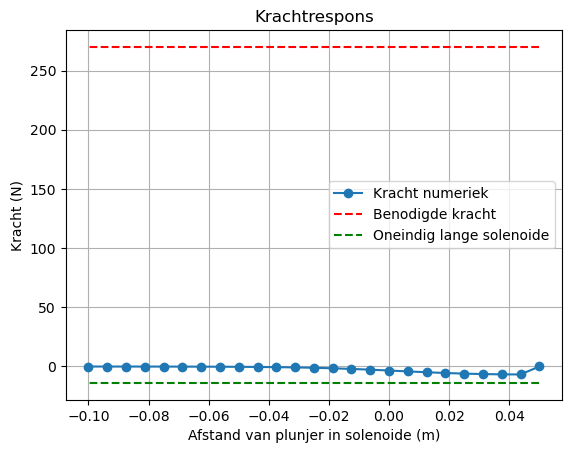

maximale numerieke kracht = 6.7140976073789895 N
benodigde kracht = 270 N
analytische kracht = 13.87913118903191 N
Conclusie: voldoet NIET aan het krachtcriterium.


In [18]:
#deurslot 9v batterij simulatie, ik heb de straal van de solenoide iets groter gemaakt dan de gegeven 0.01 meter, omdat dat anders geen oplossing gaf. De benodigde kracht is gebaseerd op een typische kracht die nodig is om een deurslot te bedienen.
L_sol_slot = 0.10
r_sol_slot = 0.05
I_slot = 0.5
N_slot = 150
F_slot = 270

z_ax_slot, H_ax_slot, Wz_slot, F_num_slot = simuleer_actuator(
    L_sol=L_sol_slot,
    r_sol=r_sol_slot,
    I=I_slot,
    N_windingen=N_slot,
    benodigde_kracht=F_slot
)

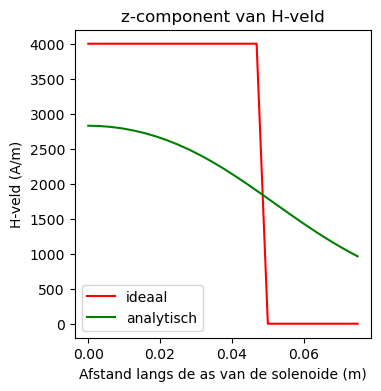

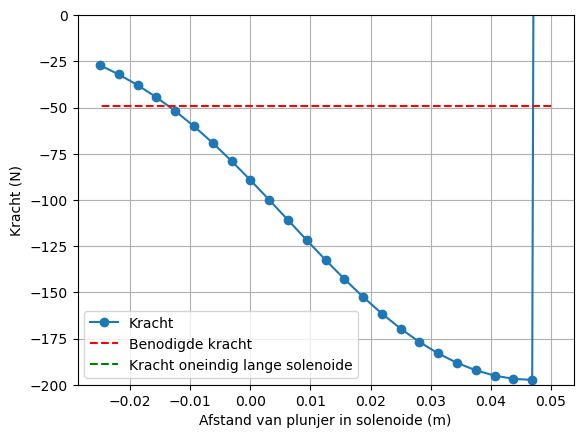

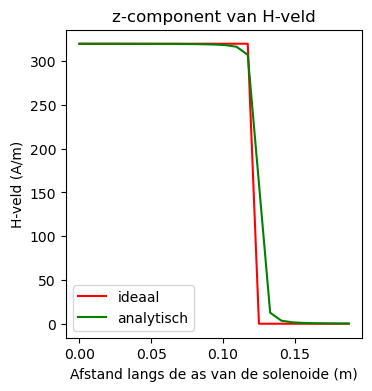

(-200.0, 0.0)

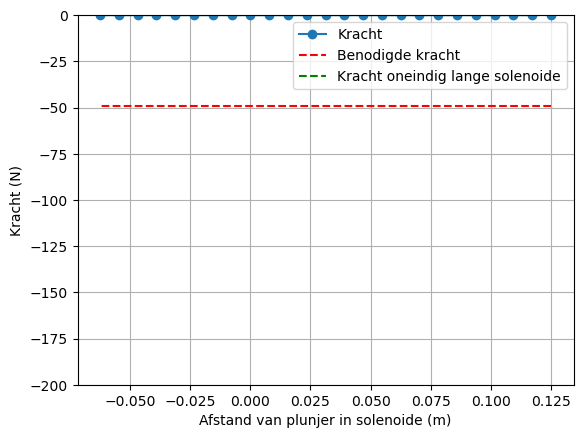

In [21]:
#deurslot

L_deurslot = 0.1 #meter
N_deurslot = 200
spoed_deurslot = N_deurslot / L_deurslot
z_ax_deurslot=np.linspace(0, 1.5*L_deurslot/2, n_ax) 

H_deurslot_ideaal=spoed_deurslot*I_deurslot*np.ones(n_ax)*(1.0*(z_ax_deurslot < L_deurslot/2)) 

# dit is nog een aardige analytische uitdrukking die je kan uitrekenen voor de z-component op de as van een solenoide met eindige lengte
H_deurslot_analytisch=(N_deurslot*I_deurslot/L_deurslot/2)*((L_deurslot/2-z_ax_deurslot)/np.sqrt((z_ax_deurslot- L_deurslot/2)**2 + r_sdeurslot**2)+(L_deurslot/2+z_ax_deurslot)/np.sqrt((z_ax_deurslot+ L_deurslot/2)**2 + r_sdeurslot**2)) 

plt.figure(figsize=[13,4])
plt.subplot(131)
plt.title('z-component van H-veld')
plt.plot(z_ax_deurslot, H_deurslot_ideaal, '-r', label='ideaal')
plt.plot(z_ax_deurslot, H_deurslot_analytisch, '-g', label='analytisch')
plt.xlabel('Afstand langs de as van de solenoide (m)')
plt.ylabel('H-veld (A/m)')
plt.legend()
plt.show()

W_deurslot = -0.5*np.pi*r_sdeurslot**2 * np.cumsum(np.flipud(H_deurslot_analytisch) * mu_r * mu_0 * np.flipud(H_deurslot_analytisch)) * (z_ax_deurslot[1] - z_ax_deurslot[0])

force_analytical2 = -mu_0*mu_r*np.pi*r_sdeurslot**2*N_deurslot**2*I_deurslot**2/2/L_deurslot**2 # Kracht uitrekenen numeriek
force_numerical2=np.diff(W_deurslot, n=1, append=[0])/(z_ax_deurslot[1] - z_ax_deurslot[0]) # Kracht uitrekenen

# Plotting the results
plt.plot(L_deurslot/2 - z_ax_deurslot, np.flipud(force_numerical2), '-o', label='Kracht')
plt.plot(L_deurslot/2 - z_ax_deurslot, (-5*9.8)*np.ones(n_ax), '--r', label='Benodigde kracht')
plt.plot(L_deurslot/2 - z_ax_deurslot, force_analytical2*np.ones(n_ax), '--g', label='Kracht oneindig lange solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Kracht (N)'), plt.grid(), plt.legend()
plt.ylim([-200, 0])

#potlood

L_potlood = 0.25 #meter
N_potlood = 2000
spoed_potlood = N_potlood / L_potlood
z_ax_potlood=np.linspace(0, 1.5*L_potlood/2, n_ax) 

H_potlood_ideaal=spoed_potlood*I_potlood*np.ones(n_ax)*(1.0*(z_ax_potlood < L_potlood/2)) 

# dit is nog een aardige analytische uitdrukking die je kan uitrekenen voor de z-component op de as van een solenoide met eindige lengte
H_potlood_analytisch=(N_potlood*I_potlood/L_potlood/2)*((L_potlood/2-z_ax_potlood)/np.sqrt((z_ax_potlood- L_potlood/2)**2 + r_spotlood**2)+(L_potlood/2+z_ax_potlood)/np.sqrt((z_ax_potlood+ L_potlood/2)**2 + r_spotlood**2)) 

plt.figure(figsize=[13,4])
plt.subplot(131)
plt.title('z-component van H-veld')
plt.plot(z_ax_potlood, H_potlood_ideaal, '-r', label='ideaal')
plt.plot(z_ax_potlood, H_potlood_analytisch, '-g', label='analytisch')
plt.xlabel('Afstand langs de as van de solenoide (m)')
plt.ylabel('H-veld (A/m)')
plt.legend()
plt.show()

W_potlood=-0.5*np.pi*r_spotlood**2*np.cumsum(np.flipud(H_potlood_analytisch)*mu_r*mu_0*np.flipud(H_potlood_analytisch))*(z_ax_potlood[1] - z_ax_potlood[0])

force_analytical3 = -mu_0*mu_r*np.pi*r_spotlood**2*N_potlood**2*I_potlood**2/2/L_potlood**2 # Kracht uitrekenen numeriek
force_numerical3=np.diff(W_potlood, n=1, append=[0])/(z_ax_potlood[1] - z_ax_potlood[0]) # Kracht uitrekenen

# Plotting the results
plt.plot(L_potlood/2 - z_ax_potlood, np.flipud(force_numerical3), '-o', label='Kracht')
plt.plot(L_potlood/2 - z_ax_potlood, (-5*9.8)*np.ones(n_ax), '--r', label='Benodigde kracht')
plt.plot(L_potlood/2 - z_ax_potlood, force_analytical3*np.ones(n_ax), '--g', label='Kracht oneindig lange solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Kracht (N)'), plt.grid(), plt.legend()
plt.ylim([-200, 0])

**Opdracht 19**

a. Kijk terug naar de criteria die jullie hebben opgesteld in vraag 5. Hebben jullie nu genoeg informatie om te beoordelen of jullie ontwerp voldoet aan de gestelde criteria, zo nee ontwerp een simpel experiment waarmee jullie het wel zouden uit kunnen voeren.
b. Beoordeel op basis van de criteria die jullie wel kunnen beoordelen of jullie idee voldoet aan jullie criteria.

Ja, we hebben genoeg informatie om te beoordelen of het ontwerp geschikt is voor onze toepassingen. De geteste simulaties tonen aan dat het namelijk niet in de buurt komt van de benodigde kracht, zowel voor de numerieke kracht als de analytische kracht.
Uit de simulatie blijkt dat de gekozen ontwerpen niet zullen werken.



Controleer eerst nog goed of alles klopt. **Klik boven op `Kernel -> Restart and Run all` en check of er geen errors zijn**. Zorg dat alle benodigde bestanden zijn geüpload in de juiste map en dat de afbeeldingen zichtbaar zijn in het notebook. Je kan nu jouw notebook opslaan, comitten en pushen naar de juiste branch! Maak dan de pull request aan en lever die in in brightspace.